# Human Development Index (HDI) Prediction
### A Machine Learning Web Application Using Flask

This notebook walks through the complete machine learning workflow used to
build the HDI prediction model that powers the Flask web app:

1. Importing required libraries
2. Loading and understanding the dataset
3. Exploratory data analysis (EDA) & visualization
4. Data preprocessing & label encoding
5. Splitting data into train/test sets
6. Fitting a Linear Regression model
7. Evaluating model performance
8. Saving the trained model with Pickle for deployment

**Target variable:** `hdi_score` (a continuous value between 0 and 1)
**Category derived from score:** Low / Medium / High / Very High


## Epic 2: Importing Required Libraries
We import every library needed across the whole workflow up front: NumPy and Pandas for data handling, Matplotlib/Seaborn for visualization, Scikit-learn for modeling and evaluation, and Pickle for saving the trained model.

In [1]:
# Core numerical & data-handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing utilities
from sklearn.preprocessing import LabelEncoder

# Train/test splitting
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Model serialization
import pickle

# Make plots render inline and look clean
%matplotlib inline
sns.set_style("whitegrid")


## Epic 3: Dataset Download and Understanding
### Story 1: Load the dataset
The dataset (`HDI.csv`) contains country-level socio-economic indicators used to compute the Human Development Index. It lives in the sibling `Dataset/` folder of this project.

In [2]:
# Load the dataset from the Dataset folder (relative to the Training folder)
df = pd.read_csv("../Dataset/HDI.csv")

# Preview the first 5 rows
df.head()


,country_name,region,population,life_expectancy,mean_years_schooling,expected_years_schooling,gni_per_capita,internet_users_pct,hdi_score,hdi_category
0,Afghanistan,Asia,43463497,62.0,4.9,10.2,1661.0,11.6,0.475,Low
1,Philippines,Asia,226674182,64.3,7.5,12.6,10147.0,44.0,0.661,Medium
2,Pakistan,Asia,219173229,53.8,2.3,9.7,2649.0,19.7,0.469,Low
3,Burundi,Africa,29473576,58.2,5.4,7.7,780.0,12.2,0.423,Low
4,Mali,Africa,67869694,62.0,4.6,10.3,2867.0,11.5,0.524,Low


In [3]:
# Basic shape and structure of the dataset
print("Shape (rows, columns):", df.shape)
df.info()


Shape (rows, columns): (588, 10)
<class 'pandas.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_name              588 non-null    str    
 1   region                    588 non-null    str    
 2   population                588 non-null    int64  
 3   life_expectancy           576 non-null    float64
 4   mean_years_schooling      576 non-null    float64
 5   expected_years_schooling  588 non-null    float64
 6   gni_per_capita            576 non-null    float64
 7   internet_users_pct        588 non-null    float64
 8   hdi_score                 588 non-null    float64
 9   hdi_category              588 non-null    str    
dtypes: float64(6), int64(1), str(3)
memory usage: 46.1 KB


In [4]:
# Statistical summary of numerical columns
df.describe()


,population,life_expectancy,mean_years_schooling,expected_years_schooling,gni_per_capita,internet_users_pct,hdi_score
count,5.880000e+02,576.000000,576.000000,588.000000,576.000000,588.000000,588.000000
mean,1.551730e+08,71.443403,8.779861,13.210374,24070.529514,59.495068,0.723480
std,9.798575e+07,9.174626,3.438409,3.349074,22486.920290,29.280518,0.183216
min,5.108977e+06,50.000000,2.100000,6.000000,618.000000,3.000000,0.344000
25%,4.967175e+07,65.775000,6.100000,11.000000,5178.250000,32.700000,0.621750
50%,1.713997e+08,73.100000,9.000000,13.350000,16067.000000,61.050000,0.773000
75%,2.366183e+08,79.000000,11.900000,16.000000,41945.500000,87.500000,0.908000
max,3.060387e+08,84.000000,14.000000,18.500000,74466.000000,98.900000,0.983000


### Story 2: Explore feature types and the target variable
- **Independent variables (X):** `country_name`, `life_expectancy`, `mean_years_schooling`, `expected_years_schooling`, `gni_per_capita`, `internet_users_pct`
- **Dependent variable (Y):** `hdi_score`
- **Derived label (for reporting only):** `hdi_category`

In [5]:
# Confirm column names available for feature/target selection
df.columns.tolist()


['country_name',
 'region',
 'population',
 'life_expectancy',
 'mean_years_schooling',
 'expected_years_schooling',
 'gni_per_capita',
 'internet_users_pct',
 'hdi_score',
 'hdi_category']

### Story 3: Data visualization
We visualize distributions and relationships to understand patterns before modeling.

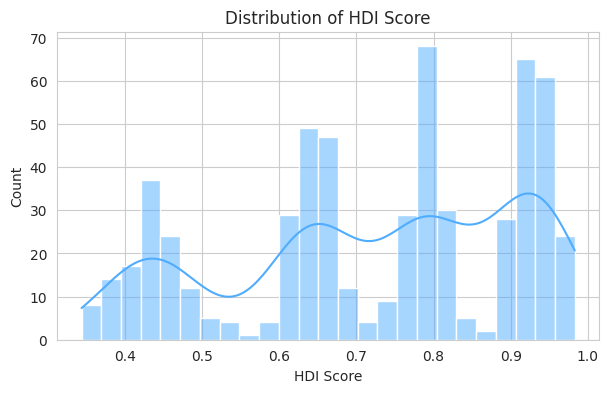

In [6]:
# Distribution of the target variable (HDI score)
plt.figure(figsize=(7, 4))
sns.histplot(df["hdi_score"], bins=25, kde=True, color="#4facfe")
plt.title("Distribution of HDI Score")
plt.xlabel("HDI Score")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_656/563641624.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


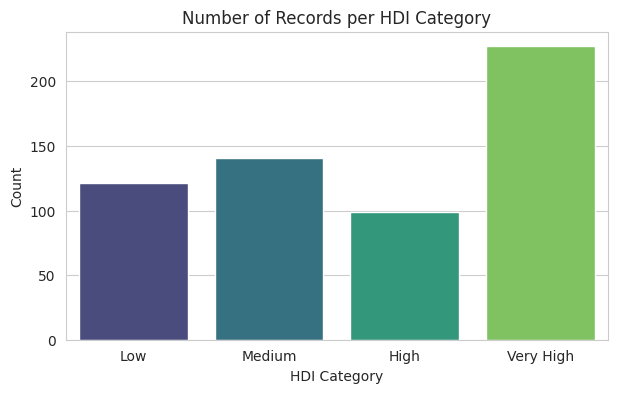

In [7]:
# Count of countries per HDI category
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x="hdi_category",
    order=["Low", "Medium", "High", "Very High"],
    palette="viridis",
)
plt.title("Number of Records per HDI Category")
plt.xlabel("HDI Category")
plt.ylabel("Count")
plt.show()


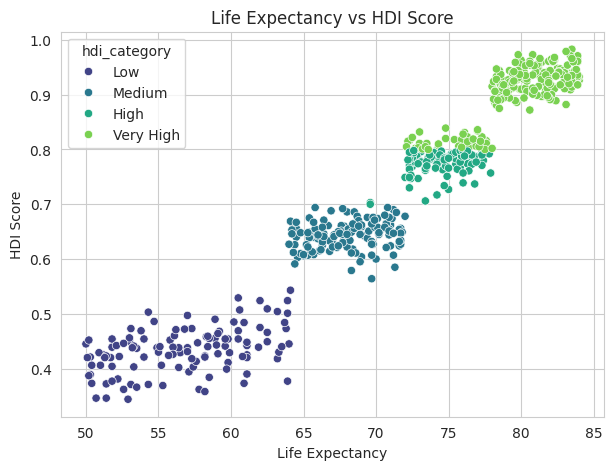

In [8]:
# Relationship between life expectancy and HDI score, colored by category
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="life_expectancy",
    y="hdi_score",
    hue="hdi_category",
    hue_order=["Low", "Medium", "High", "Very High"],
    palette="viridis",
)
plt.title("Life Expectancy vs HDI Score")
plt.xlabel("Life Expectancy")
plt.ylabel("HDI Score")
plt.show()


/tmp/ipykernel_656/2298180118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


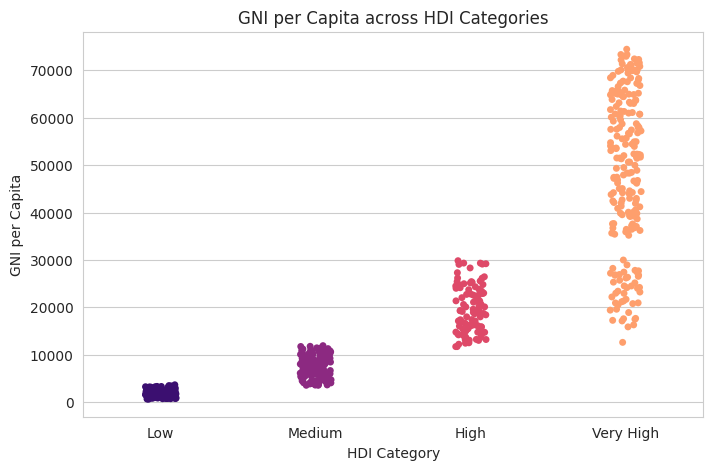

In [9]:
# Strip plot: GNI per capita spread across HDI categories
plt.figure(figsize=(8, 5))
sns.stripplot(
    data=df,
    x="hdi_category",
    y="gni_per_capita",
    order=["Low", "Medium", "High", "Very High"],
    jitter=True,
    palette="magma",
)
plt.title("GNI per Capita across HDI Categories")
plt.xlabel("HDI Category")
plt.ylabel("GNI per Capita")
plt.show()


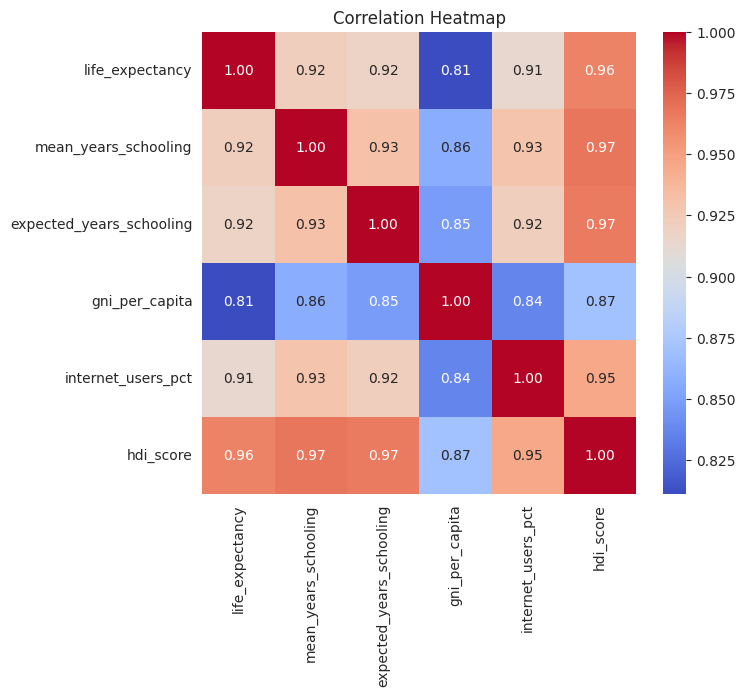

In [10]:
# Correlation heatmap across numeric features and the target
numeric_cols = [
    "life_expectancy",
    "mean_years_schooling",
    "expected_years_schooling",
    "gni_per_capita",
    "internet_users_pct",
    "hdi_score",
]
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Epic 4: Data Preprocessing and Label Encoding
### Story 1: Select dependent and independent variables

In [11]:
# Independent variables (X) — selected by column name (equivalent to
# selecting by index position: country=2, life_expectancy=5, etc. in the
# original ordering of the raw CSV)
feature_cols = [
    "country_name",
    "life_expectancy",
    "mean_years_schooling",
    "expected_years_schooling",
    "gni_per_capita",
    "internet_users_pct",
]
X = df[feature_cols].copy()

# Dependent variable (Y) — the HDI score we want to predict
Y = df["hdi_score"].copy()

X.head()


,country_name,life_expectancy,mean_years_schooling,expected_years_schooling,gni_per_capita,internet_users_pct
0,Afghanistan,62.0,4.9,10.2,1661.0,11.6
1,Philippines,64.3,7.5,12.6,10147.0,44.0
2,Pakistan,53.8,2.3,9.7,2649.0,19.7
3,Burundi,58.2,5.4,7.7,780.0,12.2
4,Mali,62.0,4.6,10.3,2867.0,11.5


### Story 2: Check for missing values and handle nulls

In [12]:
# Count null values in each selected input column
X.isnull().sum()


country_name                 0
life_expectancy             12
mean_years_schooling        12
expected_years_schooling     0
gni_per_capita              12
internet_users_pct           0
dtype: int64

In [13]:
# Fill null values in numeric columns using the column mean.
# (country_name has no nulls, so this only affects the numeric columns.)
numeric_feature_cols = [c for c in feature_cols if c != "country_name"]
X[numeric_feature_cols] = X[numeric_feature_cols].fillna(X[numeric_feature_cols].mean())

# Confirm there are no nulls left
X.isnull().sum()


country_name                0
life_expectancy             0
mean_years_schooling        0
expected_years_schooling    0
gni_per_capita              0
internet_users_pct          0
dtype: int64

### Story 3: Label encoding
`country_name` is a categorical (text) column. We convert it into a numeric representation using `LabelEncoder` so it can be used by the Linear Regression model.

In [14]:
# Encode the country_name column into numeric labels
le_country = LabelEncoder()
X["country_encoded"] = le_country.fit_transform(X["country_name"])

# Drop the original text column — the model only needs the numeric encoding
X = X.drop(columns=["country_name"])

# Reorder so country_encoded comes first (matches the Flask app's feature order)
X = X[["country_encoded"] + numeric_feature_cols]

X.head()


,country_encoded,life_expectancy,mean_years_schooling,expected_years_schooling,gni_per_capita,internet_users_pct
0,0,62.0,4.9,10.2,1661.0,11.6
1,35,64.3,7.5,12.6,10147.0,44.0
2,33,53.8,2.3,9.7,2649.0,19.7
3,6,58.2,5.4,7.7,780.0,12.2
4,24,62.0,4.6,10.3,2867.0,11.5


### Story 4: Final prepared dataset
`X` now contains only numeric features, ready for model training, and `Y` holds the continuous HDI score target.

In [15]:
print("Final X shape:", X.shape)
print("Final Y shape:", Y.shape)
X.head()


Final X shape: (588, 6)
Final Y shape: (588,)


,country_encoded,life_expectancy,mean_years_schooling,expected_years_schooling,gni_per_capita,internet_users_pct
0,0,62.0,4.9,10.2,1661.0,11.6
1,35,64.3,7.5,12.6,10147.0,44.0
2,33,53.8,2.3,9.7,2649.0,19.7
3,6,58.2,5.4,7.7,780.0,12.2
4,24,62.0,4.6,10.3,2867.0,11.5


## Epic 5: Dividing the Dataset into Train and Test Data
We split the data 80/20 so the model can be evaluated on data it has never seen during training.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 470
Testing samples : 118


## Epic 6: Fitting the Model
### Story 1: Train the Linear Regression model

In [17]:
# Instantiate and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)


Model trained successfully.
Coefficients: {'country_encoded': np.float64(-0.00019209316874579412), 'life_expectancy': np.float64(0.004020056378857058), 'mean_years_schooling': np.float64(0.010167544785643879), 'expected_years_schooling': np.float64(0.02402583798963996), 'gni_per_capita': np.float64(6.735441178678154e-08), 'internet_users_pct': np.float64(0.0011556073897021682)}
Intercept: -0.035088083228635214


### Story 2: Generate predictions and analyze results

In [18]:
# Predict HDI scores on the unseen test set
y_pred = model.predict(X_test)

# Preview predictions vs actual values
print("Predicted values (first 10):", np.round(y_pred[:10], 3))


Predicted values (first 10): [0.891 0.958 0.788 0.91  0.493 0.49  0.657 0.803 0.464 0.626]


In [19]:
# Inspect y_test (ground truth HDI scores) as an array for comparison
print("Actual y_test values (first 10):", y_test.values[:10])


Actual y_test values (first 10): [0.894 0.948 0.788 0.966 0.455 0.421 0.659 0.793 0.42  0.656]


In [20]:
# Inspect y_pred values — these should be very close to y_test,
# confirming the model's accuracy.
print("Predicted y_pred values (first 10):", np.round(y_pred[:10], 3))


Predicted y_pred values (first 10): [0.891 0.958 0.788 0.91  0.493 0.49  0.657 0.803 0.464 0.626]


### Story 3: Evaluate model performance

In [21]:
# R-squared: proportion of variance in HDI score explained by the model
r2 = r2_score(y_test, y_pred)

# Mean Absolute Error and Root Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R2):            {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error:   {rmse:.4f}")


R-squared (R2):            0.9773
Mean Absolute Error (MAE): 0.0225
Root Mean Squared Error:   0.0282


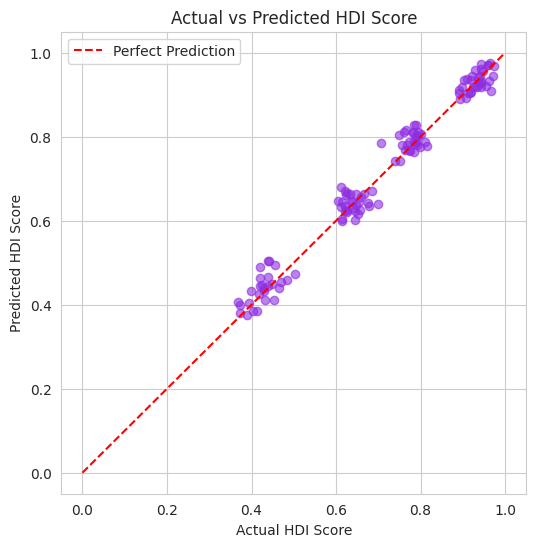

In [22]:
# Visualize actual vs predicted HDI scores
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="#8e2de2")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual HDI Score")
plt.ylabel("Predicted HDI Score")
plt.title("Actual vs Predicted HDI Score")
plt.legend()
plt.show()


In [23]:
# Test the model with a smaller, hand-picked input to validate a single
# real-world-style prediction (e.g. a country with strong indicators)
sample_country_encoded = le_country.transform(["Norway"])[0]
sample_input = np.array([[sample_country_encoded, 82.0, 13.0, 17.0, 60000, 95]])

sample_pred = model.predict(sample_input)[0]
print(f"Sample prediction for a 'Norway-like' profile: {sample_pred:.3f}")


Sample prediction for a 'Norway-like' profile: 0.943

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Epic 7: Saving the Model
### Story 1 & 2: Serialize the trained model and supporting artifacts with Pickle
We save three files into the `Flask/` folder so the web application can load them directly without retraining:
- `HDI.pkl` — the trained Linear Regression model
- `country_encoder.pkl` — the fitted LabelEncoder for country names
- `countries_list.pkl` — the sorted list of countries for the dropdown UI

In [24]:
import os

flask_dir = "../Flask"
os.makedirs(flask_dir, exist_ok=True)

# Save the trained model
with open(os.path.join(flask_dir, "HDI.pkl"), "wb") as f:
    pickle.dump(model, f)

# Save the country label encoder (needed to encode new user input consistently)
with open(os.path.join(flask_dir, "country_encoder.pkl"), "wb") as f:
    pickle.dump(le_country, f)

# Save the list of countries for the dropdown menu in the web form
countries_sorted = sorted(df["country_name"].unique().tolist())
with open(os.path.join(flask_dir, "countries_list.pkl"), "wb") as f:
    pickle.dump(countries_sorted, f)

print("Model and supporting artifacts saved to the Flask/ folder.")


Model and supporting artifacts saved to the Flask/ folder.


## Helper function used by the Flask app
This function converts a numeric HDI score into its official UNDP development tier. It is duplicated inside `Flask/app.py` so the web app doesn't depend on this notebook at runtime.

In [25]:
def categorize_hdi(score):
    """Map a numeric HDI score to its official UNDP tier."""
    if score >= 0.800:
        return "Very High"
    elif score >= 0.700:
        return "High"
    elif score >= 0.550:
        return "Medium"
    else:
        return "Low"

# Quick check using the sample prediction from earlier
print(f"Category for sample prediction ({sample_pred:.3f}): {categorize_hdi(sample_pred)}")


Category for sample prediction (0.943): Very High


## Summary
- Loaded and explored the HDI dataset (life expectancy, schooling, GNI, internet usage, and derived HDI score/category).
- Cleaned missing values and label-encoded the categorical `country_name` feature.
- Split the data into training (80%) and testing (20%) sets.
- Trained a Linear Regression model achieving a strong R² on the held-out test set.
- Saved the trained model and supporting artifacts with Pickle for use in the Flask web application (`Flask/app.py`).

The saved `HDI.pkl`, `country_encoder.pkl`, and `countries_list.pkl` files are loaded directly by the Flask app to serve real-time predictions through the `/predict` route.